## Download Dataset from Roboflow Universe

RF-DETR expects the dataset to be in COCO format. Divide your dataset into three subdirectories: `train`, `valid`, and `test`. Each subdirectory should contain its own `_annotations.coco.json` file that holds the annotations for that particular split, along with the corresponding image files. Below is an example of the directory structure:

```
dataset/
├── train/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
├── valid/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
└── test/
    ├── _annotations.coco.json
    ├── image1.jpg
    ├── image2.jpg
    └── ... (other image files)
```

[Roboflow](https://roboflow.com/annotate) allows you to create object detection datasets from scratch or convert existing datasets from formats like YOLO, and then export them in COCO JSON format for training. You can also explore [Roboflow Universe](https://universe.roboflow.com/) to find pre-labeled datasets for a range of use cases.

In [ ]:
import os
from roboflow import Roboflow
rf = Roboflow(api_key=os.environ.get("ROBOFLOW_API_KEY"))
project = rf.workspace("fyp-vfrgn").project("7-classes-vehicle")
version = project.version(1)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...


### EDA

In [ ]:
import json
import os
from collections import Counter

# Set your dataset directory path
dataset_dir = "7-classes-vehicle-1"

def analyze_coco_text_only(dataset_path, split_name):
    json_path = os.path.join(dataset_path, split_name, "_annotations.coco.json")
    
    if not os.path.exists(json_path):
        print(f"⚠️ Annotation file not found for {split_name}: {json_path}")
        return None, None
        
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Map category IDs to names
    cat_map = {c['id']: c['name'] for c in data['categories']}
    
    # Count classes
    class_counts = Counter([cat_map[ann['category_id']] for ann in data['annotations']])
    
    # Get image dimensions
    img_dims = [(img['width'], img['height']) for img in data['images']]
    
    return class_counts, img_dims

splits = ['train', 'valid', 'test']
all_sizes = []

print("=" * 60)
print(f"{'DATASET ANALYSIS':^60}")
print("=" * 60)

for split in splits:
    counts, sizes = analyze_coco_text_only(dataset_dir, split)
    
    if counts:
        all_sizes.extend(sizes)
        total_anns = sum(counts.values())
        
        print(f"\n📂 SPLIT: {split.upper()}")
        print(f"   Total Images:      {len(sizes)}")
        print(f"   Total Annotations: {total_anns}")
        print("-" * 40)
        print(f"   {'CLASS NAME':<25} | {'COUNT':<10}")
        print("-" * 40)
        
        # Print counts for each class, sorted by count descending
        for class_name, count in counts.most_common():
            print(f"   {class_name:<25} | {count:<10}")
        print("-" * 40)

# --- Image Size Analysis (Text Only) ---
if all_sizes:
    widths, heights = zip(*all_sizes)
    avg_w = sum(widths) / len(widths)
    avg_h = sum(heights) / len(heights)
    
    print("\n" + "=" * 60)
    print(f"{'IMAGE RESOLUTION STATS':^60}")
    print("=" * 60)
    print(f"   Resolution Range: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")
    print(f"   Average Resolution: {avg_w:.0f}x{avg_h:.0f}")
    print("=" * 60)

                      DATASET ANALYSIS                      

📂 SPLIT: TRAIN
   Total Images:      5820
   Total Annotations: 33389
----------------------------------------
   CLASS NAME                | COUNT     
----------------------------------------
   Pickup                    | 11672     
   Sedan                     | 11633     
   Truck                     | 5532      
   Suv                       | 2298      
   Van                       | 1669      
   Motorcycle                | 438       
   Bus                       | 147       
----------------------------------------

📂 SPLIT: VALID
   Total Images:      728
   Total Annotations: 4068
----------------------------------------
   CLASS NAME                | COUNT     
----------------------------------------
   Pickup                    | 1445      
   Sedan                     | 1414      
   Truck                     | 686       
   Suv                       | 307       
   Van                       | 168       
   Mot

## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

True
12.1
1


In [ ]:
from rfdetr.datasets.aug_config import AUG_AGGRESSIVE  # Built-in option

# custom_aug_config = {
#     "HorizontalFlip": {"p": 0.5},
#     "ShiftScaleRotate": {
#         "shift_limit": 0.05,
#         "scale_limit": 0.2,       # Increased from 0.15 — helps with vehicle size variance
#         "rotate_limit": 10,
#         "p": 0.5
#     },
#     "RandomBrightnessContrast": {
#         "brightness_limit": 0.2,  # Increased from 0.1 — simulates day/night transitions
#         "contrast_limit": 0.2,   # Increased from 0.1
#         "p": 0.4                  # Increased from 0.3
#     },
#     "OneOf": [                    # New: color variation (supported in 1.5.1)
#         {"HueSaturationValue": {"hue_shift_limit": 10, "sat_shift_limit": 20, "val_shift_limit": 20, "p": 0.5}},
#         {"RGBShift": {"r_shift_limit": 15, "g_shift_limit": 15, "b_shift_limit": 15, "p": 0.5}},
#     ],
# }

In [ ]:
from rfdetr import RFDETRSmall

model = RFDETRSmall()
history = []

def callback2(data):
	history.append(data)

model.callbacks["on_fit_epoch_end"].append(callback2)

model.train(
    dataset_dir=dataset.location,
    resolution=512,
    epochs=150,
    batch_size=4,
    grad_accum_steps=4,
    lr=5e-5,
    lr_encoder=7.5e-5,
    weight_decay=1e-4,
    aug_config=AUG_AGGRESSIVE,      
    cls_loss_coef=2.0,                 # <-- stronger classification signal
    lr_scheduler="cosine",             # <-- smooth LR decay
    warmup_epochs=1.0,                 # <-- gentle warmup
    drop_path=0.1,                     # <-- regularization
    save_dataset_grids=True,
    progress_bar=True,
    early_stopping=True,
    early_stopping_patience=20,        # <-- more patience with cosine
    early_stopping_min_delta=0.001,
    checkpoint_interval=5,
    output_dir='output_small'
)

[2026-03-26 00:06:12] [INFO] rf-detr - File rf-detr-small.pth already exists with correct MD5 hash.


[2026-03-26 00:06:12] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-26 00:06:12] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-26 00:06:12] [INFO] rf-detr - Loading pretrain weights


[2026-03-26 00:06:13] [WARNING] rf-detr - Reinitializing your detection head with 8 classes.
[2026-03-26 00:06:13] [WARNING] rf-detr - Unable to initialize TensorBoard. Logging is turned off for this session. Run 'pip install tensorboard' to enable logging.


[2026-03-26 00:06:13] [INFO] rf-detr - Not using distributed mode
[2026-03-26 00:06:13] [INFO] rf-detr - git:
  sha: 8610a3a6c6f92838b7d82bec71b31ab758498505, status: clean, branch: yolo26

[2026-03-26 00:06:13] [INFO] rf-detr - Namespace(num_classes=8, grad_accum_steps=4, print_freq=10, amp=True, lr=5e-05, lr_encoder=7.5e-05, batch_size=4, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.1, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-small.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2

...

[2026-03-26 09:12:27] [INFO] rf-detr - Evaluation results: class_error: 3.03  loss: 7.0635 (7.1279)  loss_ce: 1.2969 (1.3044)  loss_bbox: 0.0997 (0.1071)  loss_giou: 0.3529 (0.3590)  loss_ce_0: 1.3047 (1.3131)  loss_bbox_0: 0.0999 (0.1070)  loss_giou_0: 0.3636 (0.3591)  loss_ce_1: 1.2969 (1.3050)  loss_bbox_1: 0.1009 (0.1074)  loss_giou_1: 0.3555 (0.3599)  loss_ce_enc: 1.3359 (1.3264)  loss_bbox_enc: 0.1039 (0.1118)  loss_giou_enc: 0.3606 (0.3677)  loss_ce_unscaled: 0.6484 (0.6522)  class_error_unscaled: 6.2500 (8.4016)  loss_bbox_unscaled: 0.0199 (0.0214)  loss_giou_unscaled: 0.1765 (0.1795)  cardinality_error_unscaled: 279.2500 (280.2143)  loss_ce_0_unscaled: 0.6523 (0.6566)  loss_bbox_0_unscaled: 0.0200 (0.0214)  loss_giou_0_unscaled: 0.1818 (0.1796)  cardinality_error_0_unscaled: 278.7500 (278.9547)  loss_ce_1_unscaled: 0.6484 (0.6525)  loss_bbox_1_unscaled: 0.0202 (0.0215)  loss_giou_1_unscaled: 0.1777 (0.1800)  cardinality_error_1_unscaled: 284.2500 (285.9121)  loss_ce_enc_unscal

Test-ema:   0%|          | 0/182 [00:13<?, ?it/s]

[2026-03-26 09:13:24] [INFO] rf-detr - Evaluation results: class_error: 3.03  loss: 7.0035 (7.0930)  loss_ce: 1.2891 (1.3023)  loss_bbox: 0.0976 (0.1054)  loss_giou: 0.3495 (0.3550)  loss_ce_0: 1.2891 (1.3109)  loss_bbox_0: 0.0988 (0.1059)  loss_giou_0: 0.3625 (0.3562)  loss_ce_1: 1.2891 (1.3025)  loss_bbox_1: 0.0978 (0.1059)  loss_giou_1: 0.3532 (0.3562)  loss_ce_enc: 1.3203 (1.3196)  loss_bbox_enc: 0.1019 (0.1099)  loss_giou_enc: 0.3626 (0.3633)  loss_ce_unscaled: 0.6445 (0.6512)  class_error_unscaled: 7.1429 (8.2754)  loss_bbox_unscaled: 0.0195 (0.0211)  loss_giou_unscaled: 0.1748 (0.1775)  cardinality_error_unscaled: 282.0000 (282.9684)  loss_ce_0_unscaled: 0.6445 (0.6555)  loss_bbox_0_unscaled: 0.0198 (0.0212)  loss_giou_0_unscaled: 0.1813 (0.1781)  cardinality_error_0_unscaled: 282.0000 (281.7005)  loss_ce_1_unscaled: 0.6445 (0.6513)  loss_bbox_1_unscaled: 0.0196 (0.0212)  loss_giou_1_unscaled: 0.1766 (0.1781)  cardinality_error_1_unscaled: 287.2500 (287.7898)  loss_ce_enc_unscal

Eval:   0%|          | 0/182 [00:10<?, ?it/s]

[2026-03-26 09:14:19] [INFO] rf-detr - Evaluation results: class_error: 0.00  loss: 6.9214 (7.0782)  loss_ce: 1.2578 (1.2940)  loss_bbox: 0.0959 (0.1030)  loss_giou: 0.3377 (0.3536)  loss_ce_0: 1.2578 (1.3096)  loss_bbox_0: 0.0963 (0.1040)  loss_giou_0: 0.3373 (0.3556)  loss_ce_1: 1.2656 (1.2969)  loss_bbox_1: 0.0956 (0.1035)  loss_giou_1: 0.3361 (0.3548)  loss_ce_enc: 1.3047 (1.3298)  loss_bbox_enc: 0.0999 (0.1084)  loss_giou_enc: 0.3448 (0.3648)  loss_ce_unscaled: 0.6289 (0.6470)  class_error_unscaled: 7.4074 (8.4898)  loss_bbox_unscaled: 0.0192 (0.0206)  loss_giou_unscaled: 0.1688 (0.1768)  cardinality_error_unscaled: 284.5000 (284.1827)  loss_ce_0_unscaled: 0.6289 (0.6548)  loss_bbox_0_unscaled: 0.0193 (0.0208)  loss_giou_0_unscaled: 0.1687 (0.1778)  cardinality_error_0_unscaled: 281.2500 (283.1923)  loss_ce_1_unscaled: 0.6328 (0.6485)  loss_bbox_1_unscaled: 0.0191 (0.0207)  loss_giou_1_unscaled: 0.1681 (0.1774)  cardinality_error_1_unscaled: 287.7500 (287.9918)  loss_ce_enc_unscal

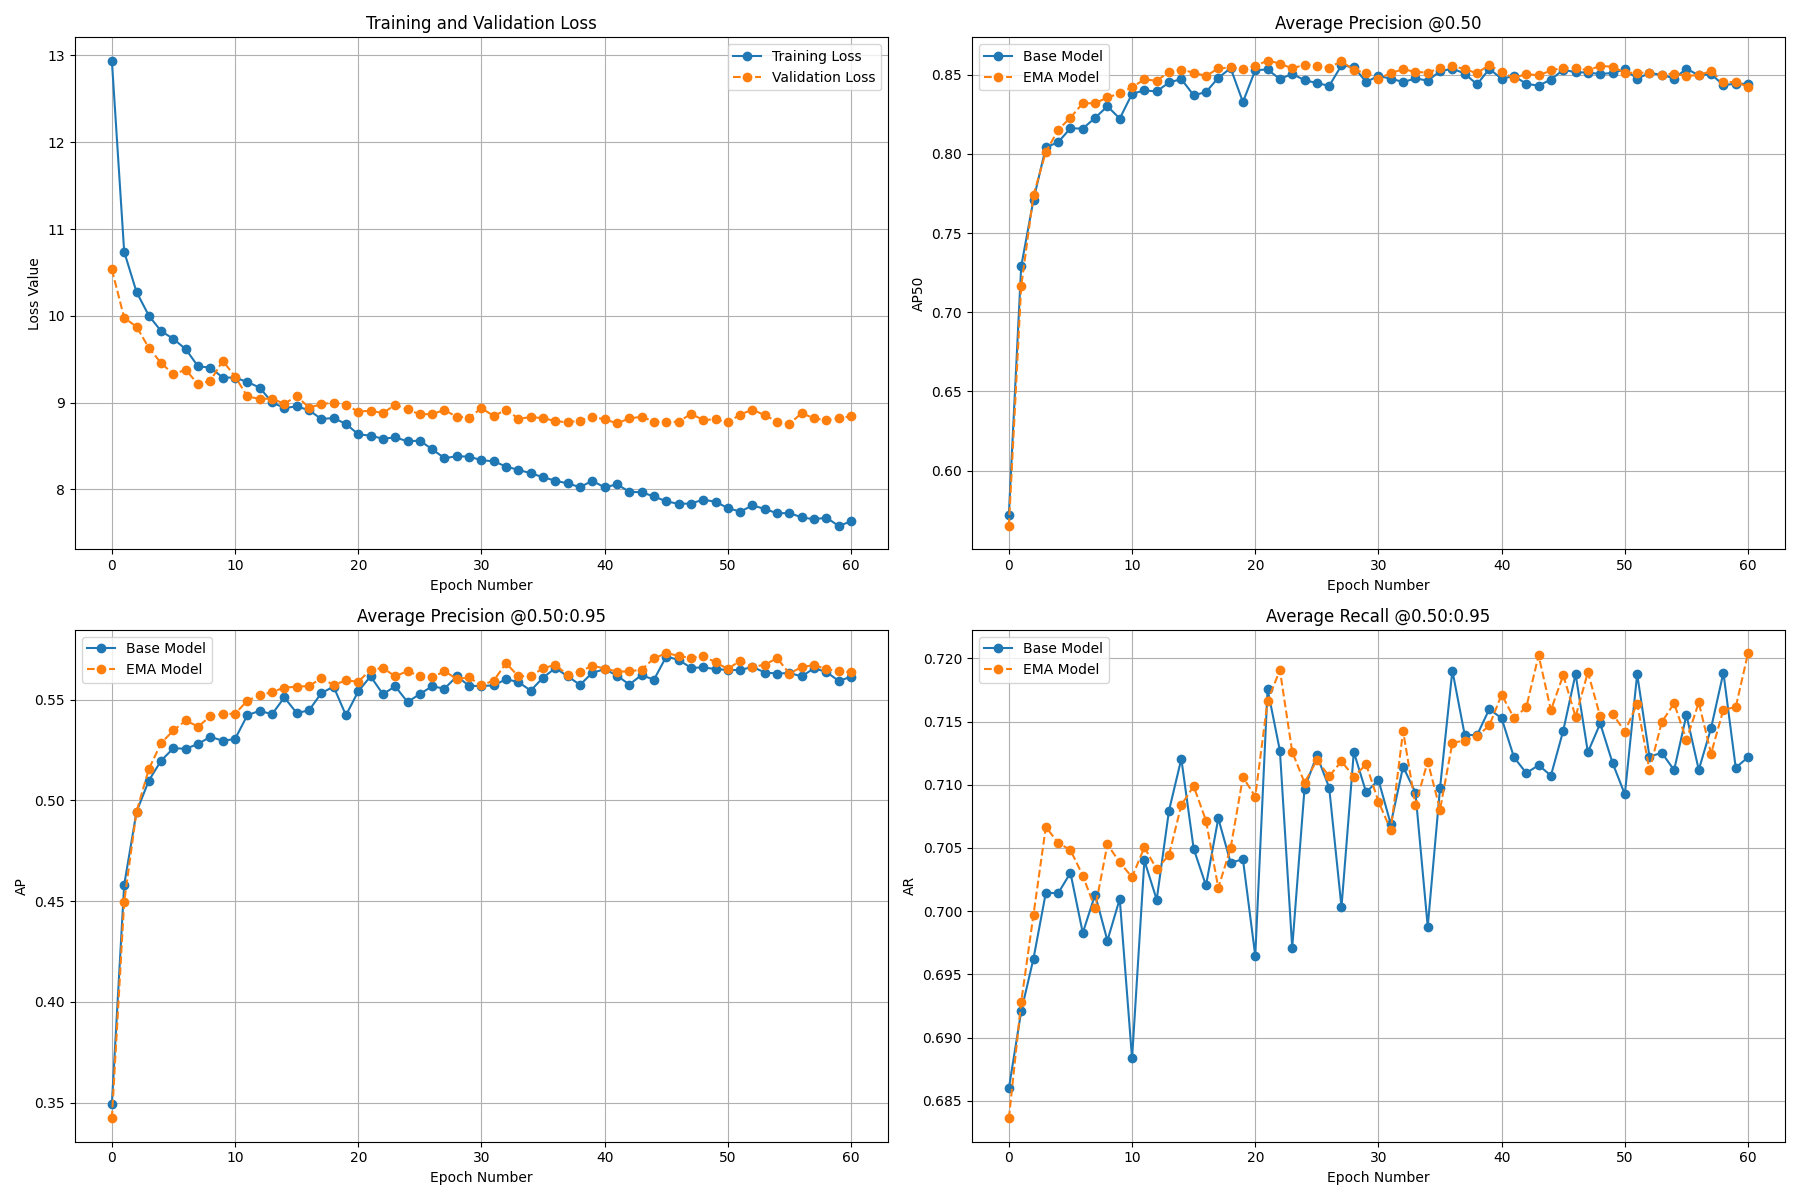

In [7]:
from PIL import Image

Image.open("output/metrics_plot.png")

## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [8]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [9]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 138.94 MB | Reserved: 4150.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 138.94 MB | Reserved: 280.00 MB


We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRMedium` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [10]:
from rfdetr import RFDETRSmall
model = RFDETRSmall(pretrain_weights="output_small/checkpoint_best_total.pth")
model.optimize_for_inference()

[2026-03-26 09:14:31] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-26 09:14:31] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-26 09:14:31] [INFO] rf-detr - Loading pretrain weights


[2026-03-26 09:14:31] [WARNING] rf-detr - Reinitializing detection head with 7 classes based on pretrained weights, configured for 90.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [11]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [12]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 726/726 [00:18<00:00, 38.48it/s]


In [13]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.563
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.859
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.676
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.334
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.580
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.746
